# Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow utilizando Reuters

* Construção de um modelo de Inteligência Artificial capaz de classificar a área específica de textos de notícias em 46 categorias diferentes (as mais comuns).
* Para isso, será utilizado o dataset de notícias do reuters, uma das maiores agências de notícias do mundo.

In [14]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [15]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow

In [16]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [17]:
# Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import reuters
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
import re

## Carregando os dados - matéria prima

https://www.cs.toronto.edu/~kriz/cifar.html

In [18]:
# Carrega os dados limitando às 10.000 palavras mais frequentes (padrão de mercado)
# Isso ajuda a ignorar palavras muito raras que só atrapalham o modelo
print("Carregando o dataset Reuters...")
(treino_dados, treino_labels), (teste_dados, teste_labels) = reuters.load_data(num_words=10000)

print(f"Notícias de treino: {len(treino_dados)}")
print(f"Notícias de teste: {len(teste_dados)}")

# Veja como uma notícia se parece (uma lista de números):
print("Exemplo da primeira notícia:", treino_dados[0])
print("Categoria (label) da primeira notícia:", treino_labels[0])

Carregando o dataset Reuters...
Notícias de treino: 8982
Notícias de teste: 2246
Exemplo da primeira notícia: [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]
Categoria (label) da primeira notícia: 3


In [19]:
# Vamos transformar as listas de números em vetores com 10.000 posições (cheios de 0 e 1)
# Isso é conhecido como "Bag of Words" (Sacola de Palavras).
def vetorizar_sequencias(sequencias, dimensao=10000):
    resultados = np.zeros((len(sequencias), dimensao))
    for i, sequencia in enumerate(sequencias):
        for j in sequencia:
            resultados[i, j] = 1. # Marca 1 se a palavra existe na notícia
    return resultados

print("Vetorizando os dados...")
x_treino = vetorizar_sequencias(treino_dados)
x_teste = vetorizar_sequencias(teste_dados)

Vetorizando os dados...


# Contrução do Modelo




In [20]:
# --- CONSTRUIR O MODELO (A ARQUITETURA DA IA) ---
print("Construindo a Rede Neural...")
modelo = keras.Sequential([
    # Camada de entrada (lê as 10.000 posições)
    layers.Dense(64, activation="relu", input_shape=(10000,)),
    # Camada oculta para aprender padrões mais complexos
    layers.Dense(64, activation="relu"),
    # Camada de saída com 46 neurônios (um para cada categoria de notícia)
    # O 'softmax' garante que a saída seja uma probabilidade (ex: 80% de chance de ser esporte)
    layers.Dense(46, activation="softmax")
])

Construindo a Rede Neural...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# --- COMPILAR O MODELO ---
modelo.compile(optimizer="rmsprop",
               loss="sparse_categorical_crossentropy", # Ideal para classificar em múltiplas categorias
               metrics=["accuracy"])

In [22]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,214 (2.47 MB)

 Trainable params: 647,214 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

# Treinamento do modelo

In [23]:
# --- TREINAR A INTELIGÊNCIA ARTIFICIAL ---
print("Iniciando o treinamento...")
historico = modelo.fit(x_treino, treino_labels,
                       epochs=50,              # Vai ler os dados
                       batch_size=2000,        # Lê 512 notícias por vez
                       validation_split=0.2)  # Separa 20% do treino para testar durante o processo

Iniciando o treinamento...
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 593ms/step - accuracy: 0.2153 - loss: 3.7041 - val_accuracy: 0.5732 - val_loss: 3.3365
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.5887 - loss: 3.0911 - val_accuracy: 0.5910 - val_loss: 2.6542
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.5967 - loss: 2.4445 - val_accuracy: 0.6066 - val_loss: 2.1615
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 536ms/step - accuracy: 0.6246 - loss: 2.0072 - val_accuracy: 0.6361 - val_loss: 1.8580
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 610ms/step - accuracy: 0.6572 - loss: 1.7141 - val_accuracy: 0.6622 - val_loss: 1.6493
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 0.6902 - loss: 1.5120 - val_accuracy: 0.6878 - val_loss: 1.5160
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.7133 - loss: 1.3651 - val_accuracy: 0.7017 - val_loss: 1.4102
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.7358 - loss: 1.2513 - val_a

## Avaliação do modelo

In [24]:
# --- AVALIAR O RESULTADO FINAL ---
print("\nAvaliação final com dados nunca vistos pelo modelo:")
resultados = modelo.evaluate(x_teste, teste_labels)
print(f"Acurácia (taxa de acerto): {resultados[1] * 100:.2f}%")


Avaliação final com dados nunca vistos pelo modelo:
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7858 - loss: 1.0040
Acurácia (taxa de acerto): 78.58%


# Matriz de Confusão

Vamos visualizar o desempenho do modelo comparando as classes reais com as previsões em uma matriz.

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


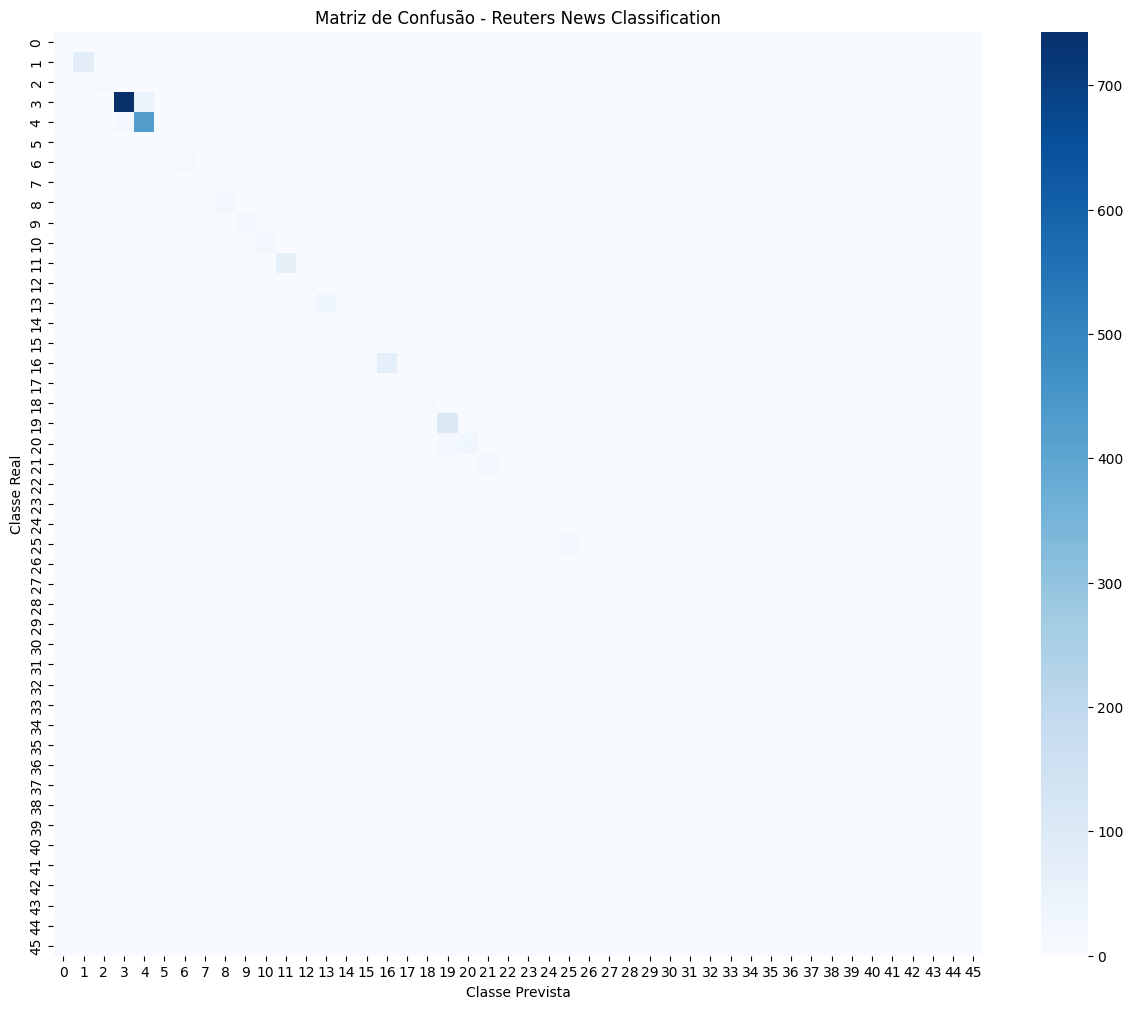

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Obter as previsões para o conjunto de teste
previsoes_teste = modelo.predict(x_teste)
categorias_previstas = np.argmax(previsoes_teste, axis=1)

# 2. Criar a matriz de confusão
cm = confusion_matrix(teste_labels, categorias_previstas)

# 3. Plotar usando Seaborn
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Matriz de Confusão - Reuters News Classification")
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")
plt.show()

## Deploy do modelo

In [26]:
# 1. Baixar o dicionário oficial (que mapeia cada palavra para um número)
dicionario_palavras = reuters.get_word_index()

# 2. Criar um pequeno dicionário com as categorias mais comuns para traduzir o resultado final
nomes_categorias = {
    0: "Cacau (cocoa)",
    1: "Agricultura/Grãos (grain)",
    2: "Óleo Vegetal (veg-oil)",
    3: "Balanços e Lucros (earn)",
    4: "Aquisições e Fusões (acq)",
    5: "Trigo (wheat)",
    6: "Cobre (copper)",
    7: "Habitação/Setor Imobiliário (housing)",
    8: "Oferta de Moeda (money-supply)",
    9: "Café (coffee)",
    10: "Açúcar (sugar)",
    11: "Comércio Internacional (trade)",
    12: "Reservas (reserves)",
    13: "Navegação/Transporte Marítimo (ship)",
    14: "Algodão (cotton)",
    15: "Carcaça/Carnes (carcass)",
    16: "Petróleo Bruto (crude)",
    17: "Gás Natural (nat-gas)",
    18: "Índice de Preços ao Consumidor (cpi)",
    19: "Câmbio e Moedas (money-fx)",
    20: "Taxas de Juros (interest)",
    21: "Produto Nacional Bruto (gnp)",
    22: "Ração/Farelo (meal-feed)",
    23: "Alumínio (alum)",
    24: "Sementes Oleaginosas (oilseed)",
    25: "Ouro (gold)",
    26: "Estanho (tin)",
    27: "Metais Estratégicos (strategic-metal)",
    28: "Pecuária (livestock)",
    29: "Varejo (retail)",
    30: "Índice de Produção Industrial (ipi)",
    31: "Ferro e Aço (iron-steel)",
    32: "Borracha (rubber)",
    33: "Petroquímica (pet-chem)",
    34: "Empregos/Mercado de Trabalho (jobs)",
    35: "Gado (l-cattle)",
    36: "Balança de Pagamentos (bop)",
    37: "Zinco (zinc)",
    38: "Laranja (orange)",
    39: "Renda (income)",
    40: "Dólar (dlr)",
    41: "Iene (yen)",
    42: "Dólar Neozelandês (nzdlr)",
    43: "Marco Alemão (dmk)",
    44: "Gás (gas)",
    45: "Chumbo (lead)"
}

# 3. A notícia que você quer testar
'''
minha_noticia = """

Petrobras discloses its proved reserves of oil, condensate and natural gas, according to SEC (U.S. Securities and Exchange Commission) regulation, estimated at 12.1 billion barrels of oil equivalent (boe), as of December 31, 2025. Oil and condensate, and natural gas correspond to 84% and 16% of this total, respectively.

In 2025, Petrobras followed the trajectory of significant reserves addition (1.7 billion boe), maintaining focus on providing value for the society and shareholders, pursuing energy security for the country's sustainable development and for a just energy transition. The reserve replacement rate (RRR) was 175%, even after a record annual production in 2025. The proved reserves-to-production ratio (R/P) is 12.5 years.

The reserves addition occurred mainly due to the outstanding performance of the assets, with emphasis on Búzios, Tupi, Itapu and Mero fields in Santos Basin, to the progress in the development of Budião, Budião Noroeste and Budião Sudeste fields in the deep waters of Sergipe-Alagoas Basin, and to new wells mainly in Búzios, Tupi, Marlim Sul and Jubarte fields in Santos and Campos basins. There were no relevant changes related to the variation in the oil price, highlighting the resilience of our projects.
"""
'''



minha_noticia = """ In São Paulo's cattle market, prices for fat cows and so-called "China-bound" cattle rose amidst a restrained supply. According to Scot Consultoria, "supplies were restrained, and yet there was sufficient volume to meet demand, but without any slack." Even with part of the meatpacking industry not buying that day, active buyers increased the prices paid. The price of cows rose R$ 3.00 per arroba (approximately 15 kg), while "China-bound" cattle increased by R$ 1.00 per arroba. The analysis also indicates that "there are deals above the reference price, but with low volume to consolidate the reference price." Slaughter schedules in the state averaged six days.
 """



# 4. Função para traduzir o texto para os números que a IA entende
def preparar_meu_texto(texto, dicionario, limite_palavras=10000):
    # Converte tudo para minúsculo e remove pontuações básicas
    texto_limpo = re.sub(r'[^\w\s]', '', texto.lower())
    palavras = texto_limpo.split()

    # O Keras reserva os números 0, 1 e 2 para "espaço vazio", "início" e "palavra desconhecida".
    # Por isso, os números das palavras reais começam a partir do 3.
    sequencia_numeros = [1] # 1 indica o início do texto

    for palavra in palavras:
        # Busca o número da palavra no dicionário
        numero = dicionario.get(palavra)

        # Se a palavra existe no dicionário e está dentro das 10.000 mais comuns
        if numero is not None and (numero + 3) < limite_palavras:
            sequencia_numeros.append(numero + 3)
        else:
            sequencia_numeros.append(2) # 2 significa "palavra desconhecida"

    return [sequencia_numeros] # Retorna dentro de uma lista

# 5. Processar a notícia
noticia_em_numeros = preparar_meu_texto(minha_noticia, dicionario_palavras)

# Reutilizamos aquela função do passo anterior para transformar em um vetor de 10.000 posições
noticia_vetorizada = vetorizar_sequencias(noticia_em_numeros)

# 6. A HORA DA VERDADE: Pedir para o modelo prever!
previsao = modelo.predict(noticia_vetorizada)

# Pega o número da categoria com a maior probabilidade
categoria_prevista = np.argmax(previsao[0])
certeza = np.max(previsao[0]) * 100

# Traduz o número para o nome legível (se estiver no nosso pequeno dicionário)
nome_legivel = nomes_categorias.get(categoria_prevista, "Outros Assuntos Financeiros/Diversos")

print("\n" + "="*50)
print("🔍 ANÁLISE DA INTELIGÊNCIA ARTIFICIAL 🔍")
print("="*50)
print(f"Texto analisado: '{minha_noticia}...'")
print(f"Categoria identificada (ID): {categoria_prevista}")
print(f"Assunto provável: {nome_legivel}")
print(f"Nível de certeza da IA: {certeza:.2f}%")
print("="*50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

🔍 ANÁLISE DA INTELIGÊNCIA ARTIFICIAL 🔍
Texto analisado: ' In São Paulo's cattle market, prices for fat cows and so-called "China-bound" cattle rose amidst a restrained supply. According to Scot Consultoria, "supplies were restrained, and yet there was sufficient volume to meet demand, but without any slack." Even with part of the meatpacking industry not buying that day, active buyers increased the prices paid. The price of cows rose R$ 3.00 per arroba (approximately 15 kg), while "China-bound" cattle increased by R$ 1.00 per arroba. The analysis also indicates that "there are deals above the reference price, but with low volume to consolidate the reference price." Slaughter schedules in the state averaged six days.
 ...'
Categoria identificada (ID): 32
Assunto provável: Borracha (rubber)
Nível de certeza da IA: 15.14%


# Conclusão

* O modelo construído com o banco de dados Reuters, diferentemente do Cifar10, trabalha com textos de notícias financeiras. Apesar disso, se assemelhaa a ele em muitos aspectos: possui um conjunto de dados prontos para treino e teste e passa por uma etapa de treino onde aprende a identificar a área das notícias analisadas com determinada acurácia.
* No resultado final, pode-se concluir que o modelo consegue identificar a área específica de notícias financeiras com uma boa acurácia. Possui suas limitações, mas é uma boa forma de avaliar como um modelo de inteligência articial lida com esse tipo de problema.